Regressione Ridge

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

In [5]:
data=fetch_california_housing(as_frame=True)
X=data.data
y=data.target
print(data.feature_names)
print(X.shape)   
print(X.describe)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
(20640, 8)
<bound method NDFrame.describe of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0

In [6]:
display(y)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

Scalo i dati

In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


inizializzo un regressione lineare per confronto sucessivo con Ridge

MSE e R2 vengono utilizzati per valutare un modello di regressione lineare.
MSE misura quanto sbagli, e gli errori sono al quadrato, errori piccoli, quasi ignorati errori grandi pesano tantissimo.
MSE pertanto 'punisce' gli errore grandi. Quindi per capire l'errore medio di MSE (errore al quadrato) bisogna calcolare la radice di MSE. 
esempio
MES=2.500  RMSE=50   errore
Attenzione, anche un solo outlier enorme fa esplodere MSE, in questo caso il modello sembra pessimo anche se è buono.
R2: il mio modello è meglio che fare una media? Confronta il risultato del modello con la media. R2 misura quando il modello è meglio della media, confrontando la somma degli errore del modello con la somma degli errore della media. R2=1-(errore modello/errore media)
Pertanto R2=1 quando errore del modello è uguale a 0 1-(0/errore media)=1
r=1 quando errore del modello =errore media (1-(errore modello/errore media))=0
L'errore del modello si ottiene confrontando y con y_pred
r2=1  errore=0 modello perfetto
r2=0  errore=errore media
tra 0 e 1 meglio della media = riduce l'errore rispetto alla media di r2%, quindi l'errore del modello è circa 100-r2% dell'errore della media
<0  peggio della media

In [20]:
lin_reg=LinearRegression()
lin_reg.fit(X_scaled,y)
y_pred_lin=lin_reg.predict(X_scaled)
#calcoliamo le metriche mse e r2
mse_lin=mean_squared_error(y,y_pred_lin)
r2_lin=r2_score(y,y_pred_lin)

print(f"MSE (Linear):\t{mse_lin:.4f} \nR2 (Linear):\t{r2_lin:.4f}")

MSE (Linear):	0.5243 
R2 (Linear):	0.6062


Ridge

In [21]:
r2_ridge=[]
mse_ridge=[]
alphas=np.logspace(-3,3,100)  #100 valore di alpha tra -3 e 3 (10alla3=1.000)

for a in alphas:
    ridge=Ridge(alpha=a)
    ridge.fit(X_scaled,y)
    y_pred=ridge.predict(X_scaled)
    mse_ridge.append(mean_squared_error(y,y_pred))
    r2_ridge.append(r2_score(y,y_pred))

risultato=pd.DataFrame({"alpha":alphas, "MSE": mse_ridge, "R2": r2_ridge})
display(risultato)

,alpha,MSE,R2
0,0.001000,0.524321,0.606233
1,0.001150,0.524321,0.606233
2,0.001322,0.524321,0.606233
3,0.001520,0.524321,0.606233
4,0.001748,0.524321,0.606233
...,...,...,...
95,572.236766,0.534411,0.598655
96,657.933225,0.536670,0.596958
97,756.463328,0.539325,0.594965
98,869.749003,0.542413,0.592645


plotto

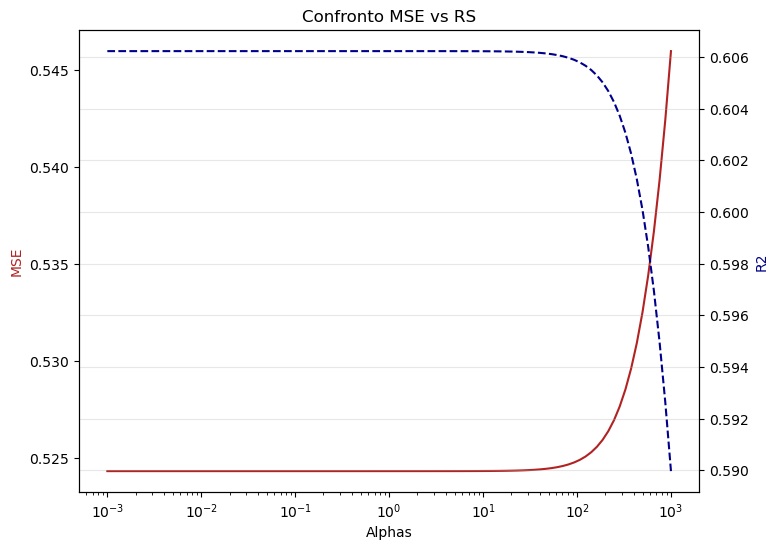

In [22]:
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(alphas,mse_ridge,"-",color="firebrick")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE",color="firebrick")

ax2=ax1.twinx()  #l'asse x è la stessa per le due linee una a sx e l'altra a dx sempre sull'asse x
ax2.plot(alphas,r2_ridge,"--",color="darkblue")
ax2.set_ylabel("R2",color="darkblue")

plt.title("Confronto MSE vs RS")
plt.grid(alpha=0.3)
plt.legend
plt.show()

RIDGECV
Alleniamo oggetto ridgecv con la cross validation usanto lo stesso intervallo di alpha

In [23]:
alphas_cv=alphas
ridge_cv=RidgeCV(alphas=alphas_cv,store_cv_results=True)
ridge_cv.fit(X_scaled,y)
print(f"Alpha RidgeCV:\t{ridge_cv.alpha_:.4f}")

y_pred_cv=ridge_cv.predict(X_scaled)
mse_cv=mean_squared_error(y,y_pred_cv)
r2_cv=r2_score(y,y_pred_cv)

print(f"MSE:\t{mse_cv:.4f}\nR2:\t{r2_cv:.4f}")

Alpha RidgeCV:	30.5386
MSE:	0.5244
R2:	0.6062


differenza MSE tra i due oggetti (0.5243, 0.5244), mentre r2 è identico per i due modelli

quale è alpha ottimale trovato allenando 100 volte un oggetto ridge cv

In [24]:
best_idx_manuale=np.argmin(mse_ridge)
best_alpha_manuale=alphas[best_idx_manuale]
best_mse_manuale=mse_ridge[best_idx_manuale]
best_r2_manuale=r2_ridge[best_idx_manuale]

print(f"Alpha Ridge:\t{best_alpha_manuale:.4f},\nMSE:\t{best_mse_manuale:.4f}\nR2:\t{best_r2_manuale:.4f}")

Alpha Ridge:	0.0010,
MSE:	0.5243
R2:	0.6062


plot del mse e r2 ma con anche i valori ottimali

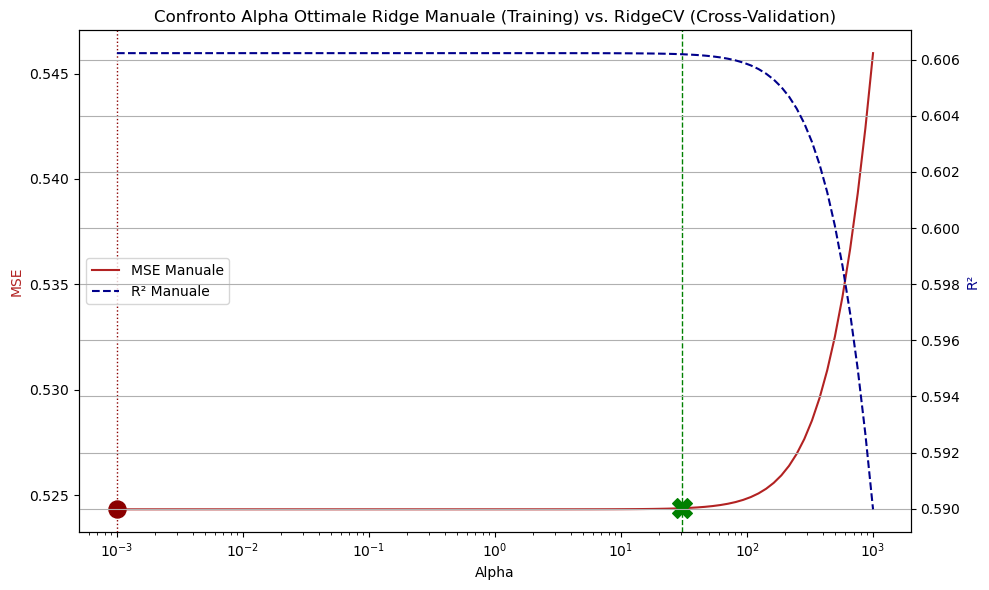

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

l1 = ax1.plot(alphas, mse_ridge, '-', color='firebrick', label='MSE Manuale')
ax1.set_xscale('log')
ax1.set_xlabel("Alpha")
ax1.set_ylabel("MSE", color='firebrick')

ax1.scatter(best_alpha_manuale, best_mse_manuale, color='darkred', s=150, zorder=5, label=f"α manuale={best_alpha_manuale:.4f}")
ax1.axvline(best_alpha_manuale, color='darkred', linestyle=':', linewidth=1)

ax1.scatter(ridge_cv.alpha_, mean_squared_error(y, ridge_cv.predict(X_scaled)),color='green', marker='X', s=200, zorder=5)
label=f"α RidgeCV={ridge_cv.alpha_:.4f}"
ax1.axvline(ridge_cv.alpha_, color='green', linestyle='--', linewidth=1)

ax2 = ax1.twinx()
l2 = ax2.plot(alphas, r2_ridge, '--', color='darkblue', label='R² Manuale')
ax2.set_ylabel("R²", color='darkblue')

plt.title(f"Confronto Alpha Ottimale Ridge Manuale (Training) vs. RidgeCV (Cross-Validation)")
plt.grid()

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='center left')

plt.tight_layout()
plt.show()